In [12]:
import pandas as pd
from matplotlib import pyplot as plt

# Zinc test set (297 structures, 43 sequence clusters), single-prediction rows from README.md "Results / Zinc".
# Structure-weighted columns match data/runs.csv; cluster-averaged columns come from the per-cluster analysis.
cols = ['config', 'attn', 'esm', 'frame', 'sw_rmse', 'sw_p2', 'sw_p5', 'ca_rmse', 'ca_p2', 'ca_p5']
rows = [
    ('sparsemax + ESM-2',   'sparsemax', True,  'absolute',  7.25, 52.9, 68.0, 12.11, 24.1, 48.6),
    ('top-k + ESM-2',       'topk',      True,  'absolute',  8.42, 49.5, 77.4, 14.20, 26.6, 59.0),
    ('softmax + ESM-2',     'softmax',   True,  'absolute',  7.55, 33.0, 67.3, 12.94, 22.0, 50.9),
    ('sparsemax, residue',  'sparsemax', False, 'residue',  12.17, 37.0, 53.9, 12.43, 34.7, 47.4),
    ('top-k, residue',      'topk',      False, 'residue',  11.44, 21.2, 50.2, 12.63, 12.6, 40.6),
    ('softmax, residue',    'softmax',   False, 'residue',  15.41, 16.5, 47.1, 13.96, 24.0, 40.9),
    ('top-k, absolute',     'topk',      False, 'absolute', 12.38, 29.0, 39.7, 13.07, 25.9, 42.7),
    ('softmax, absolute',   'softmax',   False, 'absolute', 12.64, 13.1, 46.5, 13.29, 13.8, 37.2),
    ('sparsemax, absolute', 'sparsemax', False, 'absolute', 15.58, 17.2, 27.6, 14.20, 12.9, 30.2),
    ('top-k, centroid',     'topk',      False, 'centroid', 17.38,  9.8, 38.1, 19.05,  4.2, 25.6),
    ('softmax, centroid',   'softmax',   False, 'centroid', 13.59,  8.4, 22.9, 14.15,  3.8, 23.8),
    ('sparsemax, centroid', 'sparsemax', False, 'centroid', 15.02,  9.4, 19.9, 14.54,  5.3, 19.6),
]
zn = pd.DataFrame(rows, columns=cols)

heuristic = dict(sw_rmse=8.51,  sw_p2=88.2, sw_p5=90.2, ca_rmse=13.83, ca_p2=69.7, ca_p5=78.1)
centroid  = dict(sw_rmse=17.21, sw_p2=7.1,  sw_p5=28.6, ca_rmse=18.54, ca_p2=1.1,  ca_p5=9.9)
zn

,config,attn,esm,frame,sw_rmse,sw_p2,sw_p5,ca_rmse,ca_p2,ca_p5
0,sparsemax + ESM-2,sparsemax,True,absolute,7.25,52.9,68.0,12.11,24.1,48.6
1,top-k + ESM-2,topk,True,absolute,8.42,49.5,77.4,14.20,26.6,59.0
2,softmax + ESM-2,softmax,True,absolute,7.55,33.0,67.3,12.94,22.0,50.9
3,"sparsemax, residue",sparsemax,False,residue,12.17,37.0,53.9,12.43,34.7,47.4
4,"top-k, residue",topk,False,residue,11.44,21.2,50.2,12.63,12.6,40.6
5,"softmax, residue",softmax,False,residue,15.41,16.5,47.1,13.96,24.0,40.9
6,"top-k, absolute",topk,False,absolute,12.38,29.0,39.7,13.07,25.9,42.7
7,"softmax, absolute",softmax,False,absolute,12.64,13.1,46.5,13.29,13.8,37.2
8,"sparsemax, absolute",sparsemax,False,absolute,15.58,17.2,27.6,14.20,12.9,30.2
9,"top-k, centroid",topk,False,centroid,17.38,9.8,38.1,19.05,4.2,25.6


In [13]:
YLABEL = {'rmse': 'RMSE (Å)', 'p2': '< 2 Å (%)', 'p5': '< 5 Å (%)'}
VIEWS  = [('sw', 'structure-weighted (each structure once)'),
          ('ca', 'cluster-averaged (each family once)')]
ATTN   = ['softmax', 'sparsemax', 'topk']
TICKS  = ['softmax', 'sparsemax', 'top-k']
COLORS = ['#2a78d6', '#eb6834', '#1baf7a']
REF    = [('CA-centroid baseline',    centroid,  '#898781', ':'),
          ('donor-cluster heuristic', heuristic, '#0b0b0b', '--')]


def bar_grid(series, title, metric='rmse'):
    """
    series: list of (legend label, DataFrame indexed by attn) — one bar per series within each
    attention mode. Left panel: structure-weighted; right panel: cluster-averaged, on a shared
    y-axis. metric is 'rmse', 'p2' or 'p5'. The CA-centroid baseline and donor-cluster heuristic
    are horizontal lines.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    width = 0.8 / len(series)
    for ax, (view, subtitle) in zip(axes, VIEWS):
        key   = f'{view}_{metric}'
        bars  = [ax.bar([i + (j - (len(series) - 1) / 2) * width for i in range(len(ATTN))],
                        df.loc[ATTN, key], width * 0.9, color=COLORS[j], label=label)
                 for j, (label, df) in enumerate(series)]
        lines = [ax.axhline(vals[key], color=color, ls=ls, lw=1.4, label=label)
                 for label, vals, color, ls in REF]
        ax.set_xticks(range(len(ATTN)), TICKS)
        ax.set_title(subtitle, loc='left', fontsize=10, color='#52514e')
        ax.grid(axis='y', color='#e1e0d9'); ax.set_axisbelow(True)
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
    axes[0].set_ylabel(YLABEL[metric])
    handles = bars + lines                       # bar colours first, then reference lines
    fig.legend(handles, [h.get_label() for h in handles], loc='lower center', ncol=len(handles), frameon=False)
    fig.suptitle(title)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    return fig

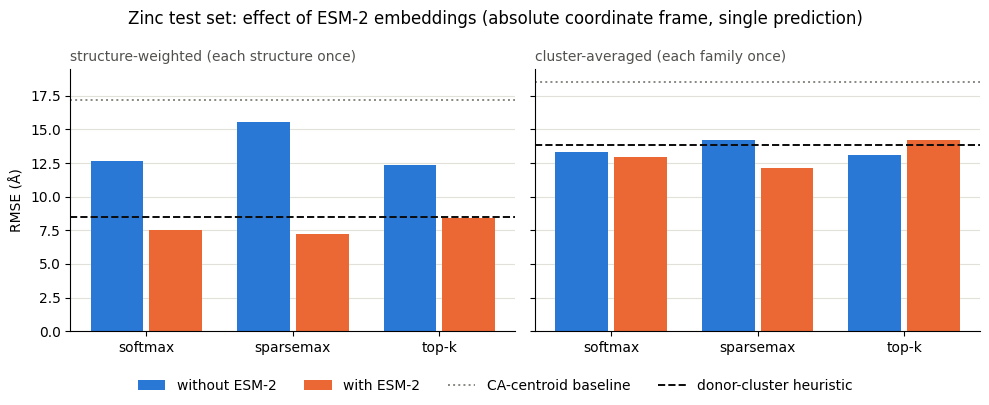

In [14]:
# Chart 1: with vs without ESM-2, absolute frame only, paired within nonlinearity
abs_frame = zn[zn.frame == 'absolute']
bar_grid(
    [('without ESM-2', abs_frame[~abs_frame.esm].set_index('attn')),
     ('with ESM-2',    abs_frame[ abs_frame.esm].set_index('attn'))],
    'Zinc test set: effect of ESM-2 embeddings (absolute coordinate frame, single prediction)',
)
plt.show()

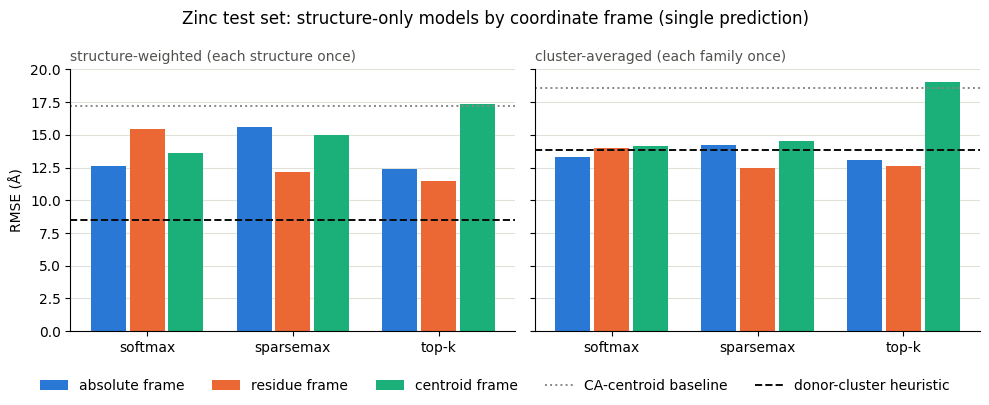

In [15]:
# Chart 2: structure-only models grouped by coordinate frame, paired within nonlinearity
no_esm = zn[~zn.esm]
bar_grid(
    [(f'{f} frame', no_esm[no_esm.frame == f].set_index('attn')) for f in ('absolute', 'residue', 'centroid')],
    'Zinc test set: structure-only models by coordinate frame (single prediction)',
)
plt.show()

In [ ]:
#residue attn weighting
# Collect per-residue attention weights over the zinc test set for the MPNN ablation set:
# MPNN only, ESM-2 only (no MPNN), and MPNN + ESM-2, in the absolute coordinate frame.
import numpy as np
import torch
from torch_geometric.loader import DataLoader

from metal_predictor.constants import DONOR_SLOTS, IDX_TO_RES
from metal_predictor.data.dataset import (MetalBindingDataset, build_metal_resname_index,
                                          cluster_aware_split, filter_by_metal_resnames, single_metal_resplit)
from metal_predictor.models.model import MetalPredictionModel

CHUNK_GLOB = 'data/gemmi_atom14/chunk_*.parquet'
CACHE_DIR  = 'data/pt_cache_v3'
CLUSTERS   = 'data/clusters/clusters.parquet'
ESM_DIR    = 'data/esm2_cache'
DEV        = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

_, _, _, c2s   = cluster_aware_split(CLUSTERS)
_, _, test_ids = single_metal_resplit(c2s, CACHE_DIR)
test_ids       = filter_by_metal_resnames(test_ids, build_metal_resname_index(CHUNK_GLOB), {'ZN'})


def attention_by_residue(checkpoint, attn, esm, mpnn_rounds=3):
    """Mean attention weight per residue type over the ZN test set, with 95% CI of the mean and count."""
    ds    = MetalBindingDataset(CHUNK_GLOB, test_ids, cache_dir=CACHE_DIR, esm_cache_dir=ESM_DIR if esm else None)
    model = MetalPredictionModel(attn_mode=attn, use_plm=esm, num_mpnn_rounds=mpnn_rounds).to(DEV)
    model.load_state_dict(torch.load(checkpoint, weights_only=True, map_location='cpu'))
    model.eval()
    res_types, weights = [], []
    with torch.no_grad():
        for b in DataLoader(ds, batch_size=16, shuffle=False):
            b = b.to(DEV)
            _, w = model(b.x, b.edge_index, b.edge_attr, b.batch, b.res_type, b.pos, b.pos_distal,
                         return_attn=True, esm=b.esm.to(DEV) if esm else None)
            res_types.append(b.res_type.cpu()); weights.append(w.cpu())
    r, w = torch.cat(res_types).numpy(), torch.cat(weights).numpy()
    rows = [(IDX_TO_RES[t], w[r == t].mean(), 1.96 * w[r == t].std() / np.sqrt((r == t).sum()), (r == t).sum())
            for t in np.unique(r)]
    return pd.DataFrame(rows, columns=['res', 'mean', 'ci', 'n']).set_index('res'), len(r) / len(test_ids)


# (row label, checkpoint suffix, use ESM-2, MPNN rounds)
ABLATION = [('MPNN only',    '',        False, 3),
            ('ESM-2 only',   '_plm_m0', True,  0),
            ('MPNN + ESM-2', '_plm',    True,  3)]
attn_stats = {}
for label, suffix, esm, rounds in ABLATION:
    for attn in ATTN:
        attn_stats[(label, attn)], mean_residues = attention_by_residue(
            f'data/best_model_v9_zn_{attn}{suffix}.pt', attn, esm, mpnn_rounds=rounds)
        top = ', '.join(f'{r} {v:.3f}' for r, v in attn_stats[(label, attn)]['mean'].nlargest(3).items())
        print(f'{label:13s} {attn:9s} top 3: {top}')
print(f'\nmean residues per test structure: {mean_residues:.0f}  → uniform weight {1 / mean_residues:.4f}')

,sw_rmse,sw_p2,sw_p5,ca_rmse,ca_p2,ca_p5
attn,,,,,,
softmax,7.39,54.55,76.09,13.42,35.00,55.76
sparsemax,7.65,49.49,70.37,11.97,25.70,53.07
topk,10.75,57.24,71.72,14.86,38.76,58.68


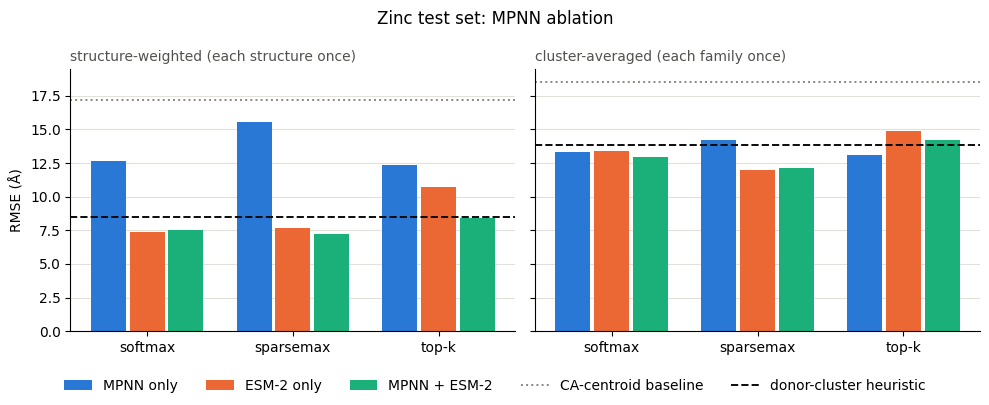

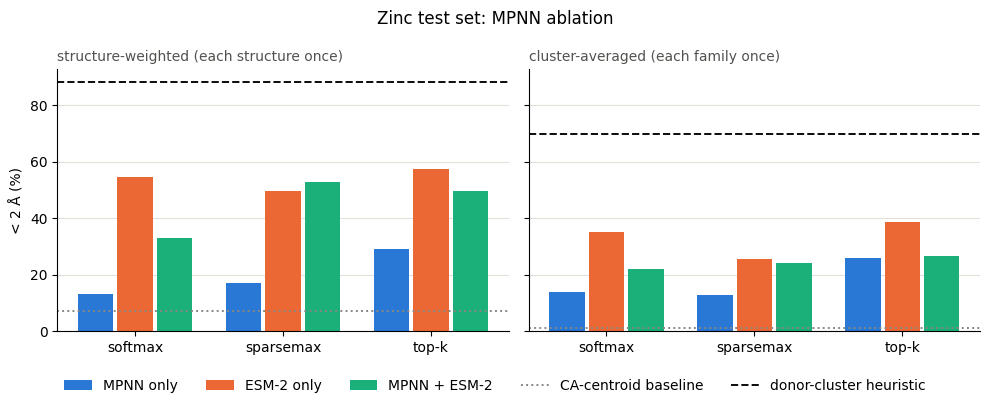

In [17]:
#Ablation Visualizations
# Chart 4: MPNN only vs ESM-2 only (MPNN ablated, --num-mpnn-rounds 0) vs MPNN + ESM-2.
# All single prediction, zinc test set, absolute coordinate frame.
# ESM-2-only rows: structure-weighted metrics are read from data/runs.csv (sweep6 runs);
# cluster-averaged metrics are not logged, so they are computed here by re-running the
# three checkpoints over the test set and averaging per MMseqs2 cluster.
import torch
from torch_geometric.loader import DataLoader
from metal_predictor.data.dataset import (MetalBindingDataset, build_metal_resname_index,
                                          cluster_aware_split, filter_by_metal_resnames, single_metal_resplit)
from metal_predictor.models.model import MetalPredictionModel

CHUNK_GLOB, CACHE_DIR, CLUSTERS = 'data/gemmi_atom14/chunk_*.parquet', 'data/pt_cache_v3', 'data/clusters/clusters.parquet'
DEV = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

_, _, _, c2s   = cluster_aware_split(CLUSTERS)
_, _, test_ids = single_metal_resplit(c2s, CACHE_DIR)
test_ids       = filter_by_metal_resnames(test_ids, build_metal_resname_index(CHUNK_GLOB), {'ZN'})
struct2cluster = {s: c for c, ss in c2s.items() for s in ss}
clusters       = [struct2cluster[s] for s in test_ids]


def cluster_averaged(checkpoint, attn):
    """RMSE / <2 Å / <5 Å computed within each cluster, then averaged over clusters."""
    ds    = MetalBindingDataset(CHUNK_GLOB, test_ids, cache_dir=CACHE_DIR, esm_cache_dir='data/esm2_cache')
    model = MetalPredictionModel(attn_mode=attn, use_plm=True, num_mpnn_rounds=0).to(DEV)
    model.load_state_dict(torch.load(checkpoint, weights_only=True, map_location='cpu'))
    model.eval()
    errs = []
    with torch.no_grad():
        for b in DataLoader(ds, batch_size=16, shuffle=False):
            b   = b.to(DEV)
            out = model(b.x, b.edge_index, b.edge_attr, b.batch, b.res_type, b.pos, b.pos_distal, esm=b.esm.to(DEV))
            errs.extend(torch.norm(out - b.y, dim=-1).cpu().tolist())
    g = pd.DataFrame(dict(cluster=clusters, err=errs)).groupby('cluster')['err']
    return dict(ca_rmse=g.apply(lambda e: (e ** 2).mean()).mean() ** 0.5,
                ca_p2=g.apply(lambda e: (e < 2).mean() * 100).mean(),
                ca_p5=g.apply(lambda e: (e < 5).mean() * 100).mean())


runs = pd.read_csv('data/runs.csv').set_index('checkpoint')
esm_only = pd.DataFrame([
    dict(attn=attn,
         sw_rmse=runs.at[f'best_model_v9_zn_{attn}_plm_m0.pt', 'test_rmse'],
         sw_p2  =runs.at[f'best_model_v9_zn_{attn}_plm_m0.pt', 'test_pct_2a'],
         sw_p5  =runs.at[f'best_model_v9_zn_{attn}_plm_m0.pt', 'test_pct_5a'],
         **cluster_averaged(f'data/best_model_v9_zn_{attn}_plm_m0.pt', attn))
    for attn in ATTN
]).set_index('attn')
display(esm_only.round(2))

ablation = [('MPNN only',    abs_frame[~abs_frame.esm].set_index('attn')),
            ('ESM-2 only',   esm_only),
            ('MPNN + ESM-2', abs_frame[ abs_frame.esm].set_index('attn'))]
ablation_title = 'Zinc test set: MPNN ablation'

bar_grid(ablation, ablation_title, metric='rmse')
plt.show()
bar_grid(ablation, ablation_title, metric='p2')
plt.show()

In [ ]:
# Chart 3: mean attention weight by residue type — MPNN only vs ESM-2 only vs MPNN + ESM-2
DONORS = set(DONOR_SLOTS)                                   # HIS / CYS / ASP / GLU
ORDER  = ['HIS', 'CYS', 'ASP', 'GLU'] + sorted(r for r in attn_stats[('MPNN only', 'softmax')].index
                                               if r not in DONORS and r != 'UNK')

fig, axes = plt.subplots(len(ABLATION), len(ATTN), figsize=(15, 8.5), sharex=True)
for row, (label, *_) in zip(axes, ABLATION):
    for ax, attn, tick in zip(row, ATTN, TICKS):
        st = attn_stats[(label, attn)].reindex(ORDER)
        ax.bar(ORDER, st['mean'], width=0.7, color=['#eb6834' if r in DONORS else '#2a78d6' for r in ORDER])
        ax.errorbar(ORDER, st['mean'], yerr=st['ci'], fmt='none', color='#52514e', capsize=2, lw=0.8)
        ax.axhline(1 / mean_residues, color='#898781', ls=':', lw=1.2)
        ax.set_title(f'{tick}, {label}', loc='left', fontsize=10, color='#52514e')
        ax.grid(axis='y', color='#e1e0d9'); ax.set_axisbelow(True)
        ax.tick_params(axis='x', rotation=90, labelsize=8)
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel('mean attention weight')

handles = [plt.Rectangle((0, 0), 1, 1, color='#eb6834'), plt.Rectangle((0, 0), 1, 1, color='#2a78d6'),
           plt.Line2D([], [], color='#898781', ls=':')]
fig.legend(handles, ['His / Cys / Asp / Glu (metal donors)', 'other residue types',
                     f'uniform attention (1 / mean residues per structure = 1/{mean_residues:.0f})'],
           loc='lower center', ncol=3, frameon=False)
fig.suptitle('Mean attention weight by residue type, zinc test set, absolute frame (y-scales differ per panel; error bars are 95% CI of the mean)')
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()